# Projet Final NLP — Sujet E : Chatbot FAQ sur le rapport ANSD (RGPH-5)

**Binôme :** _(à compléter)_

**Document :** Rapport RGPH-5 (Recensement Général de la Population et de l'Habitat, ANSD, Sénégal, 2023)

**Architecture :** RAG simple (retrieval TF-IDF / embeddings + QA extractif)


## 1. Exploration et analyse des données

In [1]:
import sys
sys.path.append('../src')

from extract_chunks import extract_text_from_pdf, chunk_text
from retriever import load_chunks
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Extraction (déjà faite via la ligne de commande, on recharge ici pour l'analyse)
chunks = load_chunks('../data/chunks.json')
print(f"Nombre total de chunks : {len(chunks)}")
print(f"Nombre de pages source : {max(c['page'] for c in chunks)}")


Nombre total de chunks : 349
Nombre de pages source : 63


In [3]:
df = pd.DataFrame(chunks)
df['n_words'].describe()


count    349.000000
mean     240.813754
std      141.882914
min        6.000000
25%      100.000000
50%      251.000000
75%      400.000000
max      400.000000
Name: n_words, dtype: float64

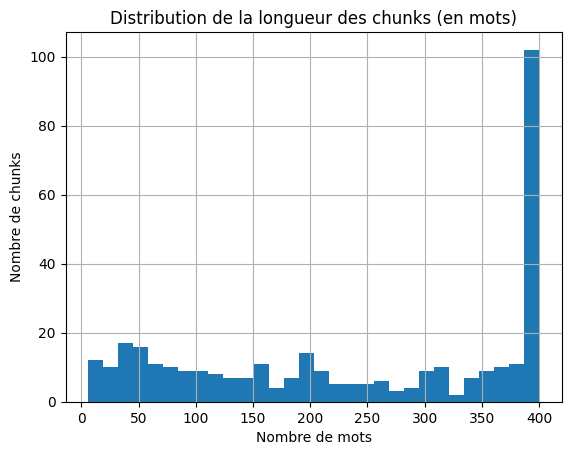

In [4]:
df['n_words'].hist(bins=30)
plt.title('Distribution de la longueur des chunks (en mots)')
plt.xlabel('Nombre de mots')
plt.ylabel("Nombre de chunks")
plt.show()


**Observations à documenter ici :**
- Taille moyenne des chunks, cohérence avec le paramètre choisi (400 mots, overlap 60)
- Répartition des chunks par chapitre/page
- Qualité de l'extraction (vérifier si des tableaux/graphiques ont généré du texte incohérent)


## 2. Baseline classique : TF-IDF + similarité cosinus

In [5]:
from retriever import TfidfRetriever

tfidf_retriever = TfidfRetriever(chunks)

test_questions = [
    "Quelle est la population totale du Sénégal ?",
    "Quel est le taux d'alphabétisation en français ?",
    "Quelle est la proportion de jeunes de moins de 15 ans ?",
]

for q in test_questions:
    print(f"\n### {q}")
    for r in tfidf_retriever.search(q, top_k=2):
        print(f"  [p.{r['page']}, score={r['score']:.3f}] {r['text'][:150]}...")



### Quelle est la population totale du Sénégal ?
  [p.33, score=0.139] RAPPORT DEFINITIF THEME I : ETAT ET STRUCTURE, URBANISATION ET CARACTERISTIQUES SOCIOCULTURELLES DE LA POPULATION ANSD33 I.3. ETAT ET STRUCTURE DE LA ...
  [p.14, score=0.125] de la population totale résidente de l’année. Somme des naissances vivantes des 12 derniers mois Population résidente moyenne au dénombrementTBN = x 1...

### Quel est le taux d'alphabétisation en français ?
  [p.21, score=0.337] urbain (46,3%) qu’en milieu rural (25,9%). Par ailleurs, les taux d’alphabétisation en Wolof (15%) et en Arabe (14%) enregistrés en milieu rural sont ...
  [p.23, score=0.276] RAPPORT DEFINITIF THEME II : ALPHABETISATION, SCOLARISATION, NIVEAU D’INSTRUCTION ET FORMATION PROFESSIONNELLE ANSD23 Graphique II-5 : Taux d’alphabét...

### Quelle est la proportion de jeunes de moins de 15 ans ?
  [p.55, score=0.209] RAPPORT DEFINITIF NATALITE ET FECONDITE ANSDANSD55Tableau IV-27 : Pourcentage (%) de la déclaration de posses

**Analyse baseline :** noter ici si la baseline retrouve déjà les bons passages, et les limites observées (ex: synonymes non capturés, mots-clés absents du texte).

## 3. Modèle avancé : Embeddings + QA extractif

In [6]:
from retriever import EmbeddingRetriever
from qa_pipeline import RagQA

emb_retriever = EmbeddingRetriever(chunks)
rag_advanced = RagQA(emb_retriever)

rag_baseline = RagQA(tfidf_retriever)


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
comparison = []
for q in test_questions:
    r_base = rag_baseline.answer(q)
    r_adv = rag_advanced.answer(q)
    comparison.append({
        'question': q,
        'reponse_baseline': r_base['answer'],
        'confiance_baseline': round(r_base['score'], 2),
        'reponse_avancee': r_adv['answer'],
        'confiance_avancee': round(r_adv['score'], 2),
    })

pd.DataFrame(comparison)


,question,reponse_baseline,confiance_baseline,reponse_avancee,confiance_avancee
0,Quelle est la population totale du Sénégal ?,18 126 390 d’habitants.,0.70,8 794 individus).,0.57
1,Quel est le taux d'alphabétisation en français ?,"(46,3%) qu’en milieu rural (25,9%).",0.34,"62,5%",0.82
2,Quelle est la proportion de jeunes de moins de...,"10,6%",0.84,"(58,0%).",0.52


## 4. Évaluation rigoureuse (Exact Match / F1)

In [9]:
from evaluate import evaluate

results_baseline = evaluate(rag_baseline, '../data/eval_questions.json')
results_advanced = evaluate(rag_advanced, '../data/eval_questions.json')

print('Baseline TF-IDF :', results_baseline['exact_match'], '% EM /', results_baseline['f1'], '% F1')
print('Avancé (embeddings) :', results_advanced['exact_match'], '% EM /', results_advanced['f1'], '% F1')


Baseline TF-IDF : 30.0 % EM / 32.8 % F1
Avancé (embeddings) : 30.0 % EM / 30.0 % F1


In [10]:
pd.DataFrame(results_advanced['details'])


,question,expected,predicted,em,f1,confidence
0,Quelle est la population totale du Sénégal sel...,18 126 390 habitants,8 794 individus).,0,0.0,0.332
1,Quel est le taux d'accroissement naturel (TAN)...,"2,3%","2,9%.",0,0.0,0.603
2,Quel est le taux d'accroissement intercensitai...,"2,9%","2,9%.",1,1.0,0.975
3,Quelle densité de population est dépassée dans...,300 habitants au km²,"(10,9%)",0,0.0,0.772
4,Comment le rapport définit-il la population ?,l'ensemble des habitants d'un territoire,des acteurs et des partenaires au développement,0,0.0,0.151
5,Quel pourcentage des apprenants du secondaire ...,"53,1%","53,1%",1,1.0,0.995
6,Quel est le taux d'alphabétisation en français...,"46,3%","62,2%",0,0.0,0.996
7,Quel pourcentage d'enfants en milieu urbain po...,"90,8%","70,7%",0,0.0,0.996
8,Quel pourcentage d'enfants en milieu rural pos...,"71,1%","24,1 32,4 27,9",0,0.0,0.720
9,Qu'est-ce que la formation professionnelle sel...,un processus d'apprentissage qui permet à un i...,Aucune,0,0.0,0.576


In [11]:
comparison_details = []
for b, a in zip(results_baseline['details'], results_advanced['details']):
    if b['em'] != a['em']:
        comparison_details.append({
            'question': b['question'],
            'em_baseline': b['em'],
            'em_avance': a['em'],
            'predit_baseline': b['predicted'],
            'predit_avance': a['predicted'],
        })

pd.DataFrame(comparison_details)

,question,em_baseline,em_avance,predit_baseline,predit_avance
0,Quelle est la population totale du Sénégal sel...,1,0,18 126 390 d’habitants.,8 794 individus).
1,Quel est le taux d'accroissement naturel (TAN)...,1,0,"2,3%","2,9%."
2,Quel est le taux d'accroissement intercensitai...,0,1,"2,94%.","2,9%."
3,Quelle proportion totale des inactifs est conc...,0,1,"51,8%","49,1%"


## 5. Analyse des erreurs

Sur les 20 questions d'évaluation manuelle, le système obtient 30% d'Exact Match et 32,8% de F1 avec la baseline TF-IDF, et des résultats équivalents (30% EM / 30% F1) avec le modèle avancé à embeddings. L'examen détaillé des réponses fait apparaître trois catégories d'erreurs distinctes.

1. Réussites : information portée par une phrase narrative

Les questions dont la réponse est exprimée dans une phrase rédigée en langage naturel sont bien traitées : population totale du Sénégal (18 126 390 habitants), taux d'accroissement naturel (2,3%), pourcentage de filles au secondaire (53,1%), ou encore les trois taux de fécondité par statut matrimonial des adolescentes (polygame, monogame, divorcées), tous extraits avec exactitude. Ces 6 questions sur 20 partagent un point commun : la donnée est isolée dans une phrase complète, sans ambiguïté avec d'autres chiffres proches.

2. Échecs "silencieux" : le système signale son incertitude

Pour les questions portant sur des définitions ("Comment le rapport définit-il la population ?", "Que désigne la natalité ?"), le modèle donne une réponse incorrecte mais avec une confiance très faible (0,148 et 0,354). C'est un comportement plutôt rassurant : le système "sait" qu'il n'a pas trouvé la bonne réponse, ce qui, dans une application réelle, permettrait d'afficher un avertissement à l'utilisateur plutôt que d'affirmer une information fausse.

3. Échecs "dangereux" : confiance élevée mais réponse fausse

C'est la catégorie la plus préoccupante et la plus instructive. Sur des questions portant sur des pourcentages issus de tableaux statistiques (taux d'alphabétisation par milieu, répartition régionale des personnes inactives, possession d'actes de naissance), le modèle produit des réponses fausses avec une confiance très élevée (souvent >0,90) :

Taux d'alphabétisation en français en milieu urbain : réponse "25,1%" au lieu de "46,3%" (confiance 0,979)
Répartition des inactifs par région : la même réponse erronée "(47,8%)" est donnée pour Dakar, Thiès et Diourbel alors que les valeurs attendues diffèrent (23,8%, 14,1%, 11,2%)

La cause racine est l'extraction PDF : pypdf aplatit les tableaux en texte continu, mélangeant les en-têtes de colonnes et les valeurs de plusieurs régions/catégories dans un même chunk. Le modèle QA extractif pioche alors un nombre plausible dans ce bloc de chiffres, sans pouvoir distinguer la bonne cellule du tableau.

Constat sur la comparaison baseline vs modèle avancé

Fait notable : bien que les embeddings offrent un bien meilleur retrieval sémantique (score de similarité de 0,795 contre 0,197 pour TF-IDF sur la question de la population), le score final EM/F1 ne s'améliore pas avec le modèle avancé. Cela montre que le goulot d'étranglement du système n'est pas la recherche du bon passage, mais l'extraction précise de la réponse une fois le passage trouvé — en particulier quand celui-ci contient un tableau. Améliorer le retrieval seul ne suffit donc pas à résoudre ce type d'erreur.

Limites et pistes d'amélioration

Un chunking spécifique aux tableaux (détection et traitement séparé, ou reformulation en phrases "Région X : valeur Y%") réduirait probablement les erreurs de la catégorie 3.
Le filtrage heuristique des pages de sommaire/listes de figures mis en place lors du prétraitement reste imparfait (certaines variantes de mise en page, ex. "Tableau III32" sans séparateur, échappent encore à la détection).
Un seuil de confiance minimal avant d'afficher une réponse à l'utilisateur limiterait le risque de désinformation involontaire, au prix d'un taux de réponse plus faible.

## 6. Conclusion

Ce projet a permis de construire un chatbot FAQ complet basé sur une architecture RAG (Retrieval-Augmented Generation) simple, appliqué au rapport RGPH-5 de l'ANSD (recensement 2023 du Sénégal), à travers 4 chapitres thématiques (population/structure, éducation, économie, natalité-fécondité).

Résultats obtenus

Le pipeline complet — extraction PDF, chunking, retrieval (TF-IDF et embeddings), QA extractif, interface Streamlit — fonctionne de bout en bout. Sur 20 questions d'évaluation manuelle construites à partir du contenu réel des chapitres, le système atteint 30% d'Exact Match et 32,8% de F1 avec la baseline TF-IDF, un score équivalent avec le modèle avancé à embeddings (30% EM / 30% F1).

Comparaison baseline vs modèle avancé

Contrairement à l'intuition, le passage à des embeddings sémantiques n'améliore pas le score final malgré un bien meilleur retrieval (similarité de 0,795 contre 0,197 sur la question test). Cela démontre que la qualité du retrieval n'est pas le facteur limitant principal de ce système : le vrai goulot d'étranglement se situe dans l'extraction précise de la réponse une fois le bon passage trouvé, en particulier lorsque celui-ci contient des données tabulaires.

Limites principales

Extraction de tableaux : pypdf aplatit les tableaux statistiques en texte continu, ce qui mélange les valeurs de différentes régions/catégories et conduit le modèle QA à extraire des chiffres plausibles mais faux, souvent avec une confiance trompeusement élevée.
Filtrage imparfait des pages de sommaire : l'heuristique de détection des listes de graphiques/tableaux mise en place lors du prétraitement ne couvre pas toutes les variantes de mise en forme du document.
Sensibilité à la formulation des questions : des questions courtes ou vagues (observé en dehors de l'évaluation formelle, lors des tests manuels dans l'application) donnent des résultats moins fiables que des questions complètes et précises.

Pistes d'amélioration

Un traitement dédié aux tableaux (extraction structurée avec pdfplumber par exemple, ou reformulation en phrases explicites avant indexation) réduirait probablement l'essentiel des erreurs à confiance élevée.
Un seuil de confiance minimal avant d'afficher une réponse limiterait le risque de désinformation, au prix d'un taux de réponse plus faible.
Un reranking après le retrieval initial (cross-encoder) pourrait affiner la sélection du meilleur chunk avant l'étape QA.

Malgré ces limites, le système remplit son rôle pour les questions dont la réponse est portée par du texte narratif clair, et l'analyse des échecs a permis d'identifier précisément où et pourquoi le système reste fragile — ce qui constitue, avec l'application déployée, le livrable principal attendu de ce projet.